In [67]:
from typing import List, Tuple

import os
import subprocess
import pickle
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

#### Utilities

In [68]:
def generate_ba_graph_nx(n0: int, n: int, m: int) -> nx.Graph | None:
    tmp_filename = "temporary-graph.txt"

    try:
        result = subprocess.run(
            ["../build/generate_graph", str(2), str(n0), str(m), str(n), tmp_filename],
            check=True,
        )
    except subprocess.CalledProcessError as e:
        print(f"Error generating graph: {e}")
        os.remove(tmp_filename) if os.path.exists(tmp_filename) else None
        return None

    if result.returncode != 0:
        print(f"Graph generation failed with return code {result.returncode}")
        os.remove(tmp_filename) if os.path.exists(tmp_filename) else None
        return None
    
    try:
        with open(tmp_filename, "r") as f:
            graph_data = f.read()
    except Exception as e:
        print(f"Error reading file {tmp_filename}: {e}")
        os.remove(tmp_filename) if os.path.exists(tmp_filename) else None
        return None

    graph = nx.Graph()
    for line in graph_data.splitlines():
        node1, node2 = [int(node) for node in line.strip().split()]
        graph.add_edge(node1, node2)

    return graph

In [69]:
def contrack_graph(graph: nx.Graph) -> nx.Graph:
    for (u, v) in graph.edges():
        if graph.degree[u] == 2:
            return contrack_graph(nx.contracted_nodes(graph, v, u, copy=False, self_loops=False))
        if graph.degree[v] == 2:
            return contrack_graph(nx.contracted_nodes(graph, u, v, copy=False, self_loops=False))
    return graph

In [70]:
def count_subdivisions(n0: int, n: int, m: int, repetitions: int) -> Tuple[List[int], List[int]]:
    k5_subdivisions = []
    k33_subdivisions = []

    non_planar_count = 0
    while non_planar_count < repetitions:
        graph = generate_ba_graph_nx(n0, n, m)
        is_planar, subgraph = nx.check_planarity(graph, True)
        
        if is_planar:
            continue

        non_planar_count += 1
        nodes_number_in_subgraph = subgraph.number_of_nodes()

        contracted_subgraph = contrack_graph(subgraph)    
        degs_set = set(dict(contracted_subgraph.degree()).values())
        if degs_set == {3}:
            k33_subdivisions.append(nodes_number_in_subgraph)
        elif degs_set == {4}:
            k5_subdivisions.append(nodes_number_in_subgraph)
        else:
            print("Unexpected degree set:", degs_set)

    return k5_subdivisions, k33_subdivisions

In [85]:
# GRAPH_N0 = 10
# GRAPH_N_VALUES = list(range(50, 1000 + 1, 50))
# GRAPH_M_VALUES = list(range(4, 6 + 1, 1))

# K5_SUBGRAPH = nx.complete_graph(5)
# K33_SUBGRAPH = nx.complete_bipartite_graph(3, 3)

# REPETITIONS = 10000
# ALWAYS_REWRITE = True

GRAPH_N0 = 10
GRAPH_N_VALUES = list(range(50, 500 + 1, 150))
GRAPH_M_VALUES = list(range(6, 6 + 1, 1))

K5_SUBGRAPH = nx.complete_graph(5)
K33_SUBGRAPH = nx.complete_bipartite_graph(3, 3)

REPETITIONS = 10
ALWAYS_REWRITE = True

In [86]:
for m in GRAPH_M_VALUES:
    output_filename = f"cache/subdivisions_m{m}.pkl"
    if os.path.exists(output_filename) and not ALWAYS_REWRITE:
        continue

    k5_subdivisions_counts = []
    k33_subdivisions_counts = []

    for n in GRAPH_N_VALUES:
        k5_count, k33_count = count_subdivisions(GRAPH_N0, n, m, REPETITIONS)
        k5_subdivisions_counts.append(k5_count)
        k33_subdivisions_counts.append(k33_count)

    with open(output_filename, "wb") as f:
        pickle.dump((GRAPH_N_VALUES, k5_subdivisions_counts, k33_subdivisions_counts), f)

Processing n=50, m=6
Processing n=250, m=6
Processing n=450, m=6
Processing n=650, m=6
Processing n=850, m=6


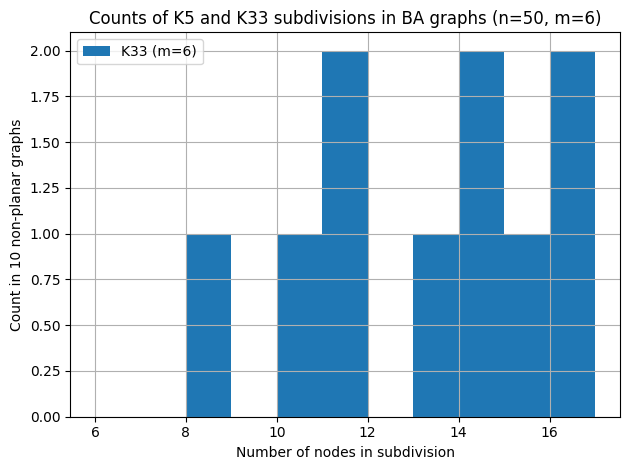

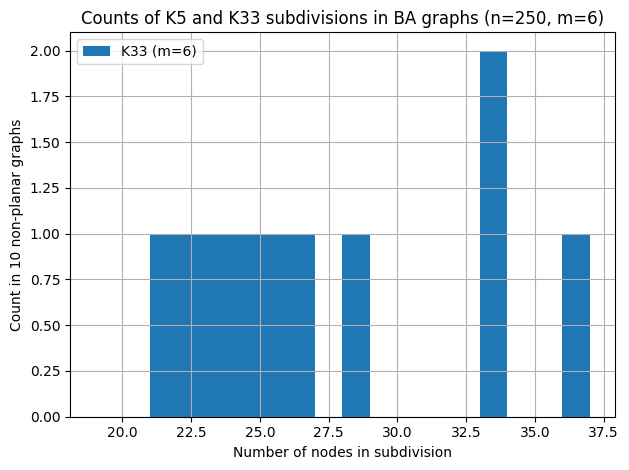

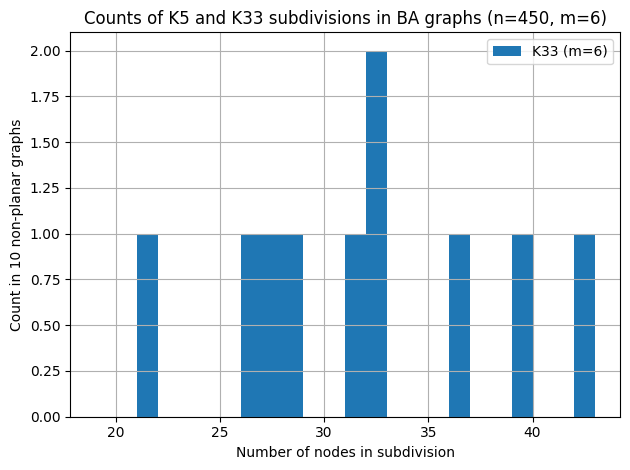

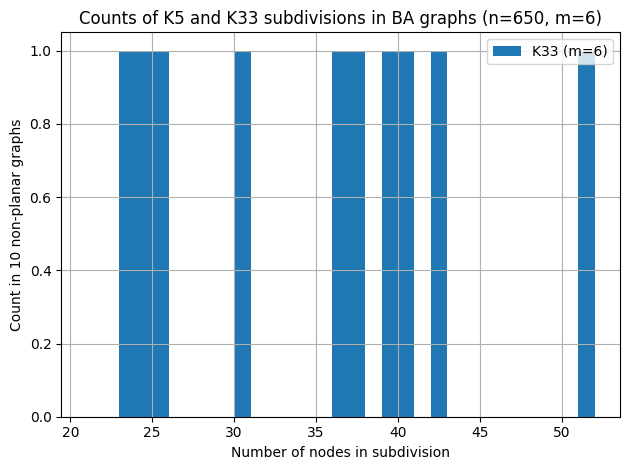

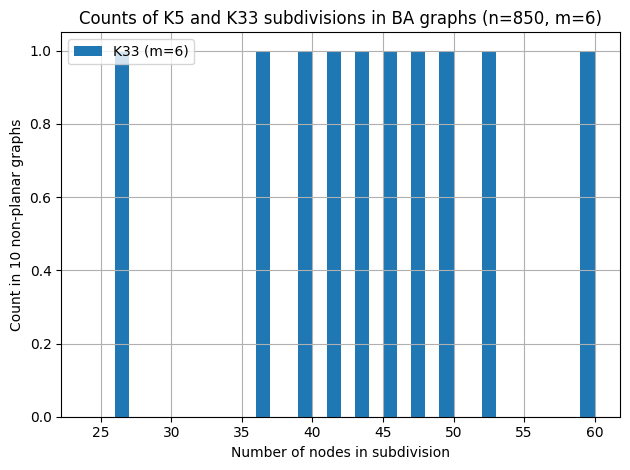

In [88]:
for m in GRAPH_M_VALUES:
    with open(f"cache/subdivisions_m{m}.pkl", "rb") as f:
        n_values, k5_counts, k33_counts = pickle.load(f)
    
    for n, k5, k33 in zip(n_values, k5_counts, k33_counts):
        if len(k33) > 0:
            plt.hist(
                k33, bins=np.arange(min(k33) - 2, max(k33) + 2), label=f"K33"
            )
        
        if len(k5) > 0:
            plt.hist(
                k5, bins=np.arange(min(k5) - 2, max(k5) + 2), label=f"K5"
            )

        plt.xlabel("Number of nodes in subdivision")
        plt.ylabel(f"Count in {REPETITIONS} non-planar graphs")
        plt.title(f"Counts of K5 and K33 subdivisions in BA graphs (n={n}, m={m})")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"ba_subdivisions_n{n}_m{m}.png")
        plt.show()